# Mathober 2026

From <https://mathober.com/>:

> Mathober is a space for everyone to explore and express creativity. Take a prompt and use any medium to engage with the prompts in your own way. No rules, just have fun and discover.

## Common setup

In [1]:
import io
import math

import cairo
import IPython.display


def display_svg(svgio: io.BytesIO) -> None:
    IPython.display.display(IPython.display.SVG(svgio.getvalue().decode()))

## Day 1: Perimeter of an Ellipse

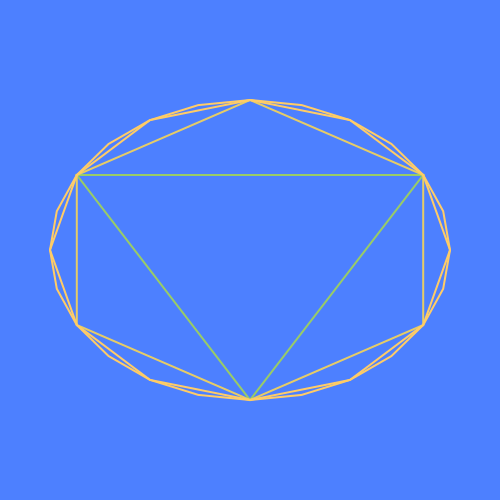

In [2]:
svgio = io.BytesIO()
canvas_size = 500
min_polygon_sides = 0
max_polygon_sides = 3
ellipse_radius_big = 200
ellipse_radius_small = 150
ellipse_radius_variation = 0


with cairo.SVGSurface(svgio, canvas_size, canvas_size) as surface:
    context = cairo.Context(surface)

    # Background
    context.rectangle(0, 0, canvas_size, canvas_size)
    context.set_source_rgb(0.3, 0.5, 1)
    context.fill()

    # Incribed polygons
    context.translate(canvas_size / 2, canvas_size / 2)

    for i in range(min_polygon_sides, max_polygon_sides + 1):
        sides = 3 * 2 ** i
        ratio = (sides - min_polygon_sides) / (max_polygon_sides - min_polygon_sides)
        a = ellipse_radius_big - (1 - ratio) * ellipse_radius_variation
        b = ellipse_radius_small - (ellipse_radius_small / ellipse_radius_big) * (1 - ratio) * ellipse_radius_variation

        context.scale(a, b)

        for j in range(sides):
            angle = (1 / 4 + j / sides) * 2 * math.pi
            context.line_to(math.cos(angle), math.sin(angle))

        context.close_path()
        context.set_source_rgb(0.3 + 0.3 * ratio, 0.8, 0.4)
        context.scale(1 / a, 1 / b)
        context.set_line_width(2)
        context.stroke()


display_svg(svgio)